In [2]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb


In [4]:

import joblib
import os

model_save_dir = "../models/"
os.makedirs(model_save_dir, exist_ok=True)

In [5]:
df = pd.read_csv('../data/heart_processed.csv')
   

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (736, 18)
Testing set shape: (184, 18)


In [7]:
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,1,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


### Feature Scaling 


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled[:5]

array([[-0.06314684,  1.56027016, -0.10359879, -0.41469811, -0.62720514,
         1.3022944 , -0.80788285, -0.35792038,  0.5249412 , -0.48252546,
         1.84585634, -0.23007121, -1.20894105, -0.49745113,  0.65295987,
        -0.55014077, -1.65985001,  1.91264943],
       [ 2.1805258 , -0.11641087, -0.10359879, -0.41469811,  0.08762742,
        -0.76787553, -0.33582682, -0.35792038,  0.5249412 , -0.48252546,
         1.84585634, -0.23007121,  0.82717019, -0.49745113,  0.65295987,
        -0.55014077,  0.60246408, -0.52283497],
       [-0.06314684, -0.45174708, -0.0383732 , -0.41469811, -0.62720514,
         1.3022944 ,  1.08034128, -0.35792038,  0.5249412 , -0.48252546,
        -0.54175397, -0.23007121,  0.82717019, -0.49745113,  0.65295987,
        -0.55014077, -1.65985001,  1.91264943],
       [ 0.79158559,  0.44248281, -0.70926495, -0.41469811,  0.00820158,
         1.3022944 ,  0.98593007,  1.26818703,  0.5249412 , -0.48252546,
        -0.54175397, -0.23007121, -1.20894105, -0.497

## Logistic Regression

In [10]:
results = {}
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
log_reg_grid.fit(X_train_scaled, y_train)
log_reg_best = log_reg_grid.best_estimator_

y_pred = log_reg_best.predict(X_test_scaled)
results['Logistic Regression'] = {
    'best_params': log_reg_grid.best_params_,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'confusion_matrix': confusion_matrix(y_test, y_pred)
}


Fitting 5 folds for each of 10 candidates, totalling 50 fits


## Support Vector Machine

In [11]:
svc = SVC(random_state=42, probability=True)
svc_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svc_grid = GridSearchCV(svc, svc_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svc_grid.fit(X_train_scaled, y_train)
svc_best = svc_grid.best_estimator_

y_pred = svc_best.predict(X_test_scaled)
results['Support Vector Machine'] = {
    'best_params': svc_grid.best_params_,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'confusion_matrix': confusion_matrix(y_test, y_pred)
}


Fitting 5 folds for each of 12 candidates, totalling 60 fits


Random Forest

In [12]:
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_

y_pred = rf_best.predict(X_test_scaled)
results['Random Forest'] = {
    'best_params': rf_grid.best_params_,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'confusion_matrix': confusion_matrix(y_test, y_pred)
}


Fitting 5 folds for each of 180 candidates, totalling 900 fits


## XGBoost


In [13]:
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_scaled, y_train)
xgb_best = xgb_grid.best_estimator_

y_pred = xgb_best.predict(X_test_scaled)
results['XGBoost'] = {
    'best_params': xgb_grid.best_params_,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'confusion_matrix': confusion_matrix(y_test, y_pred)
}


Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\Users\dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:26:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Naive Bayes

In [14]:

nb = GaussianNB()
nb_params = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

nb_grid = GridSearchCV(nb, nb_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
nb_grid.fit(X_train_scaled, y_train)
nb_best = nb_grid.best_estimator_

y_pred = nb_best.predict(X_test_scaled)
results['Naive Bayes'] = {
    'best_params': nb_grid.best_params_,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'confusion_matrix': confusion_matrix(y_test, y_pred)
}


Fitting 5 folds for each of 100 candidates, totalling 500 fits


## Performance Comparision

In [15]:

print("Model Comparison")

comparison_data = [
    {
        'Model': 'Logistic Regression',
        'Accuracy': results['Logistic Regression']['accuracy'],
        'Precision': results['Logistic Regression']['precision'],
        'Recall': results['Logistic Regression']['recall'],
        'F1-Score': results['Logistic Regression']['f1_score']
    },
    {
        'Model': 'Support Vector Machine',
        'Accuracy': results['Support Vector Machine']['accuracy'],
        'Precision': results['Support Vector Machine']['precision'],
        'Recall': results['Support Vector Machine']['recall'],
        'F1-Score': results['Support Vector Machine']['f1_score']
    },
    {
        'Model': 'Random Forest',
        'Accuracy': results['Random Forest']['accuracy'],
        'Precision': results['Random Forest']['precision'],
        'Recall': results['Random Forest']['recall'],
        'F1-Score': results['Random Forest']['f1_score']
    },
    {
        'Model': 'XGBoost',
        'Accuracy': results['XGBoost']['accuracy'],
        'Precision': results['XGBoost']['precision'],
        'Recall': results['XGBoost']['recall'],
        'F1-Score': results['XGBoost']['f1_score']
    },
    {
        'Model': 'Naive Bayes',
        'Accuracy': results['Naive Bayes']['accuracy'],
        'Precision': results['Naive Bayes']['precision'],
        'Recall': results['Naive Bayes']['recall'],
        'F1-Score': results['Naive Bayes']['f1_score']
    }
]

results_df = pd.DataFrame(comparison_data)

results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False)


print("Model Comparison Table:")
print(results_df_sorted.to_string(index=False))
results_csv_path = "../results/model_comparison.csv"
results_df.to_csv(results_csv_path, index=True)

Model Comparison
Model Comparison Table:
                 Model  Accuracy  Precision   Recall  F1-Score
               XGBoost  0.836957   0.839623 0.872549  0.855769
         Random Forest  0.831522   0.819820 0.892157  0.854460
Support Vector Machine  0.815217   0.798246 0.892157  0.842593
   Logistic Regression  0.804348   0.811321 0.843137  0.826923
           Naive Bayes  0.798913   0.828283 0.803922  0.815920


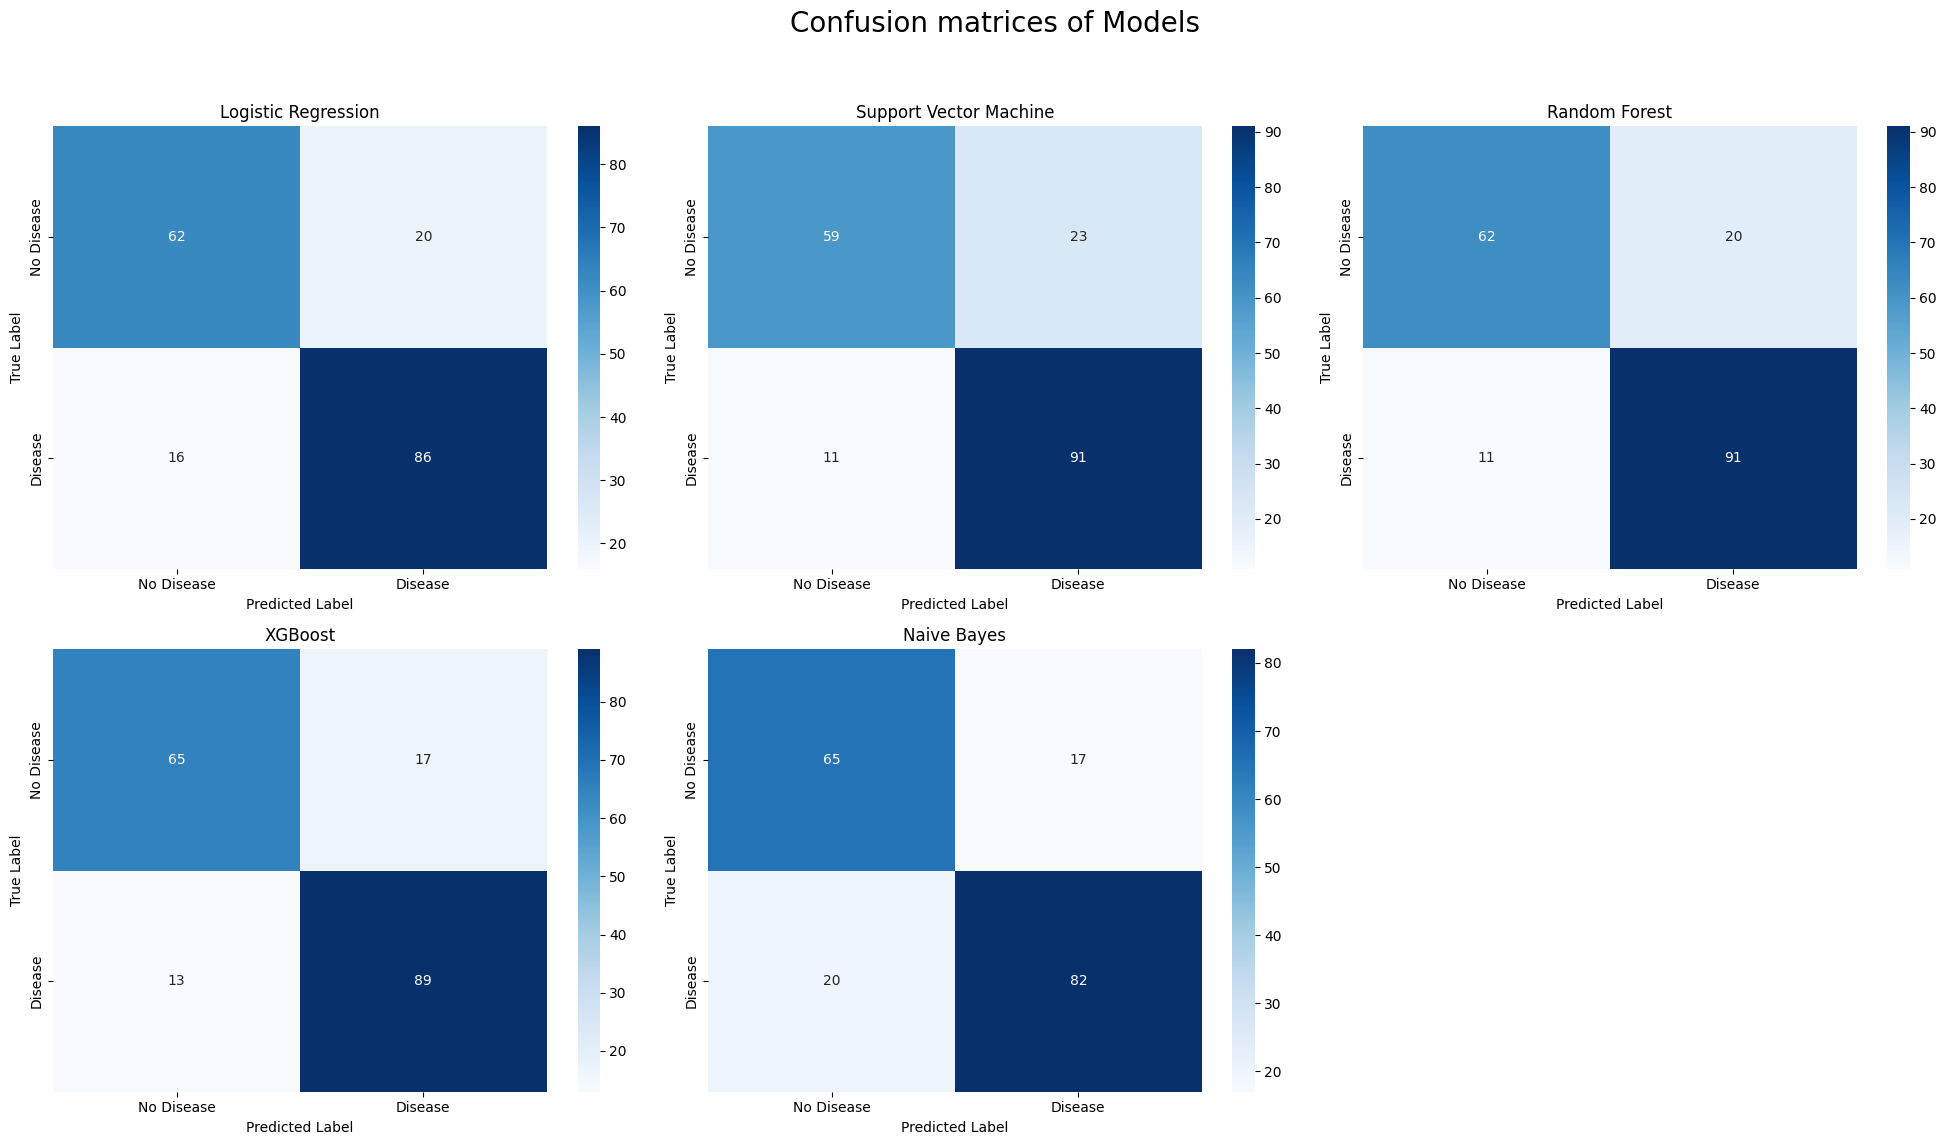

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
fig.suptitle('Confusion matrices of Models', fontsize=20)
axes = axes.flatten()

for i, (name, data) in enumerate(results.items()):
    ax = axes[i]
    sns.heatmap(data['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

for i in range(len(results), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
